# Test lc_multi_outputs Extension

This notebook tests that the lc_multi_outputs JupyterLab extension is properly installed and enabled.
- Test multi_outputs basic functionality (pin button and output saving)

## Parameters

In [1]:
# Default parameters (will be overridden by Papermill)
notebook7_url = "http://localhost:8888/tree"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmph48wcfav


In [4]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

import scripts.notebook7
importlib.reload(scripts.notebook7)

from scripts.playwright import *
from scripts.notebook7 import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251204-164210',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpu8x3znks')

## Open Jupyter Notebook and wait for it to load

Start epoch: 1764834130.962028 seconds


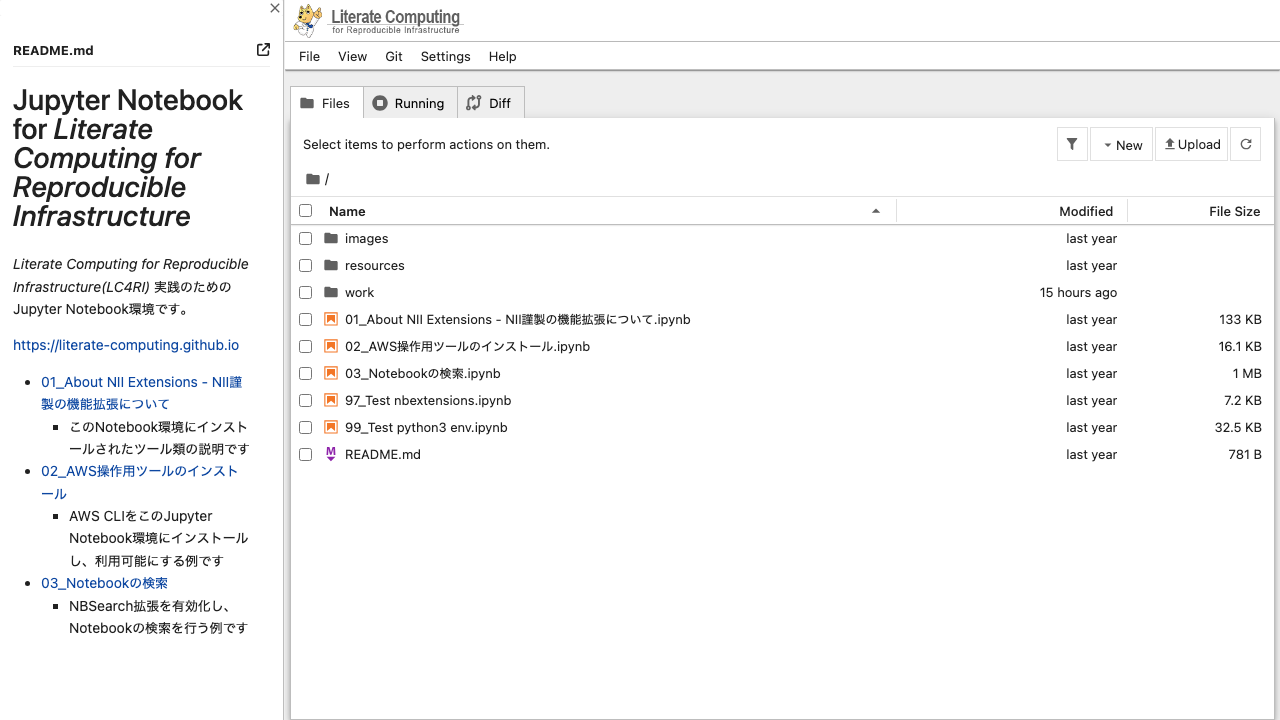

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{notebook7_url}?token={jupyter_token}")

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

await run_pw(_step_wait_for_loading)

## Create a new notebook for testing multi_outputs

Start epoch: 1764834133.28529 seconds


✓ New notebook created


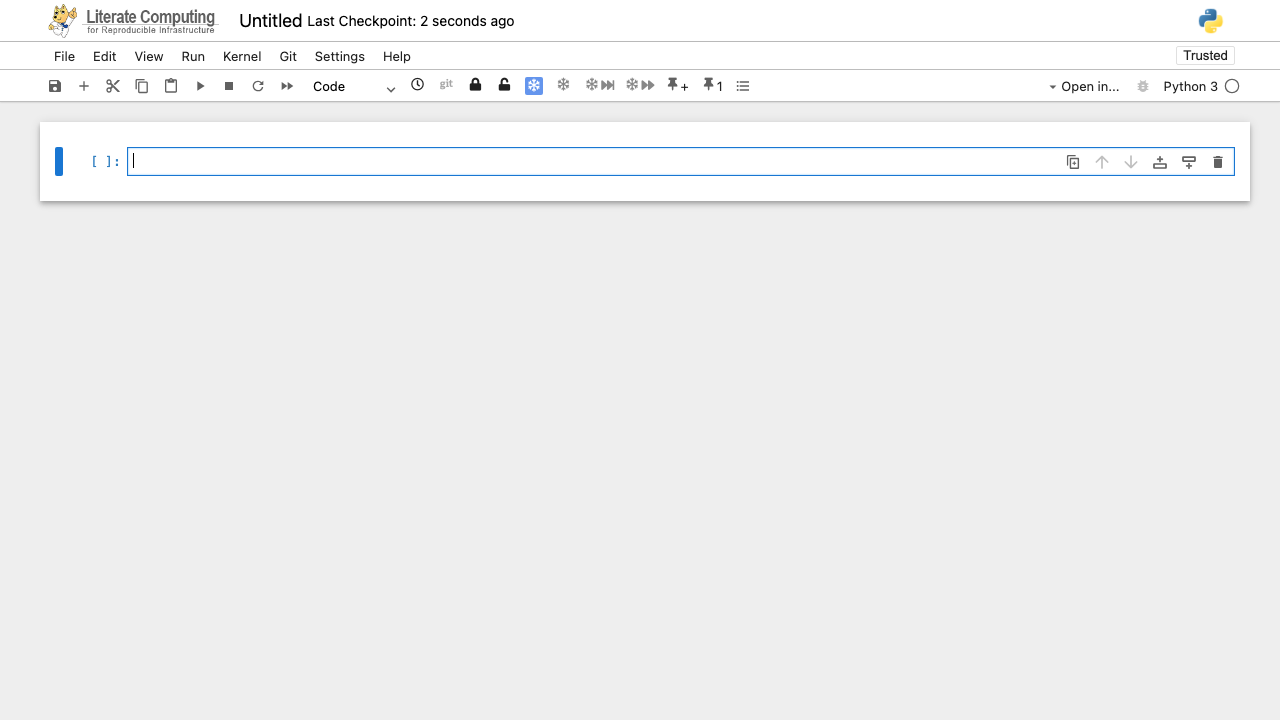

In [6]:
async def _step_create_notebook(page):
    # Create a new notebook using the notebook7 helper
    new_page = await create_new_notebook(page, kernel="Python 3", timeout=transition_timeout)
    print("✓ New notebook created")
    return new_page

await run_pw(_step_create_notebook)

## Execute a cell with output to trigger multi_outputs

Start epoch: 1764834136.1082501 seconds


✓ Cell executed


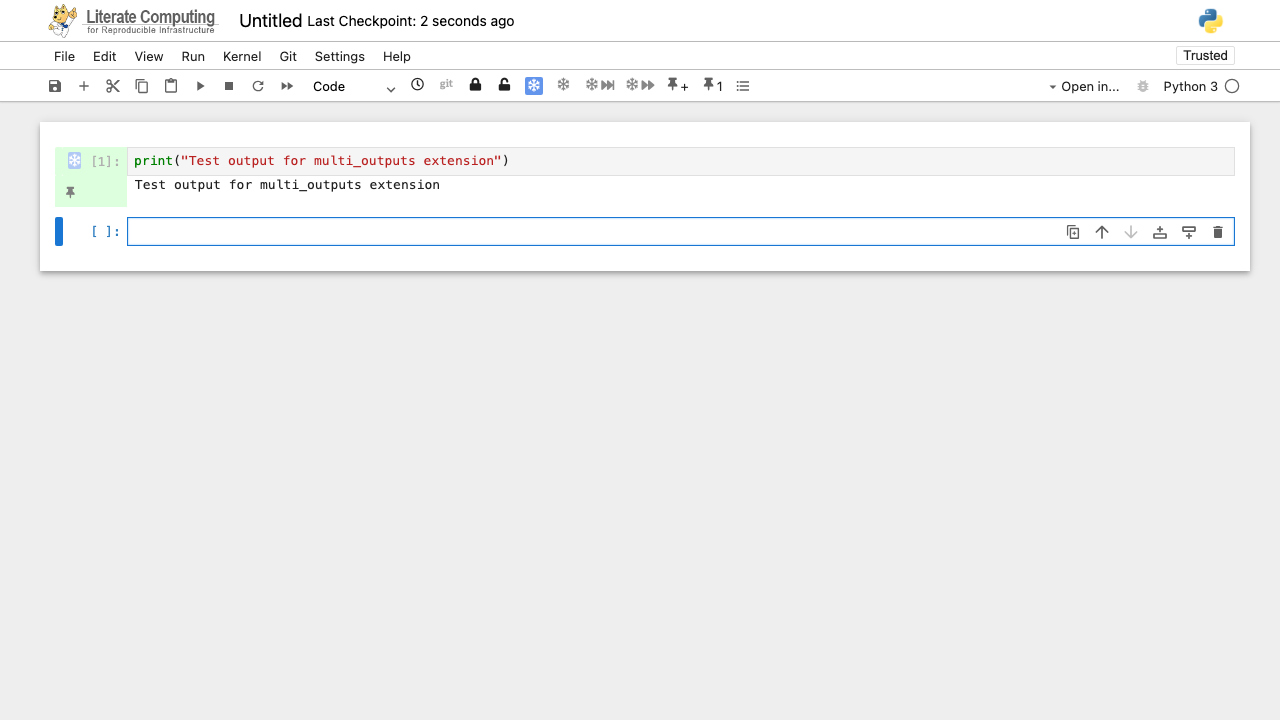

In [7]:
async def _step_execute_cell(page):
    # Use a simple print statement that will show in the output area
    await set_cell(page, 0, "code", 'print("Test output for multi_outputs extension")', timeout=transition_timeout)

    # Execute the cell
    await run_cell(page, 0, True, timeout=transition_timeout)
        
    # Wait a bit for the multi_outputs extension to add its UI elements
    await page.wait_for_timeout(1000)
    
    print("✓ Cell executed")

await run_pw(_step_execute_cell)

## Test multi_outputs basic functionality (pin button and output saving)

Start epoch: 1764834143.0122612 seconds


✓ Multi-outputs UI verified (pin button, tabs, and output rendering)


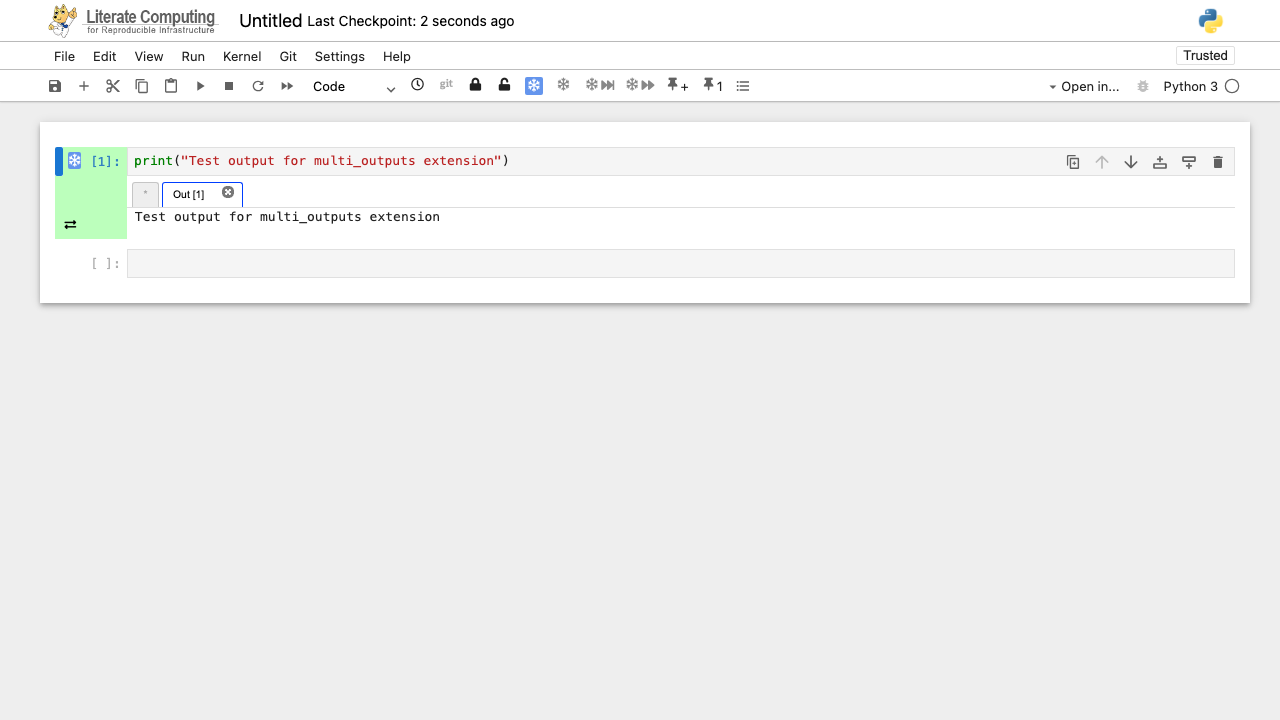

In [8]:
async def _step_verify_multi_outputs(page):
    # Get the first cell
    await select_cell(page, 0, timeout=transition_timeout)
    cell = await get_cell(page, 0, timeout=transition_timeout)

    # Click pin button on the first cell
    output_ui = cell.locator('.multi-outputs-ui')
    pin_button = output_ui.locator('button')
    await expect(pin_button).to_be_visible(timeout=transition_timeout)
    await pin_button.click()

    # Check that there are tabs
    multi_outputs_widget = cell.locator('.multi-output-widget')
    await expect(multi_outputs_widget).to_be_visible(timeout=transition_timeout)
    multi_output_tabs = multi_outputs_widget.locator('.multi-output-tabs')
    await expect(multi_output_tabs).to_be_visible(timeout=transition_timeout)

    # Check that there are current tab and the first tab
    current_tab = multi_output_tabs.locator('li#tab-output-current')
    await expect(current_tab).to_be_visible(timeout=transition_timeout)
    first_tab = multi_output_tabs.locator('li#tab-output-1')
    await expect(first_tab).to_be_visible(timeout=transition_timeout)

    # Check that the output is rendered properly
    output_wrapper = multi_outputs_widget.locator('.multi-output-wrapper#output-1')
    await expect(output_wrapper).to_be_visible(timeout=transition_timeout)
    output_text = await output_wrapper.locator('.jp-RenderedText.jp-OutputArea-output').text_content()
    assert "Test output" in output_text, f"Expected output not found. Got: {output_text}"

    print("✓ Multi-outputs UI verified (pin button, tabs, and output rendering)")


await run_pw(_step_verify_multi_outputs)

## Cleanup

In [ ]:
await finish_pw_context()

In [10]:
!rm -rf {work_dir}